# Book - Modern Time Series Forecasting with Python

## Chapter 08 - Feature-Based Machine Learning for Time Series Forecasting


### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* sklearn: 1.3.2
* seaborn: 0.13.2
* statsmodels: 0.14.1


### Loading libries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split,TimeSeriesSplit, KFold,GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error # For evaluation
import statsmodels.api as sm

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [2]:
print("--- Load and Visualize AirPassengers Data ---")
try:
    # Use the pre-packaged AirPassengers dataset from statsmodels
    air_passengers_data = sm.datasets.get_rdataset("AirPassengers", "datasets", cache=True).data
    # Ensure proper datetime indexing
    air_passengers_data['year'] = air_passengers_data['time'].astype(int)
    air_passengers_data['month'] = ((air_passengers_data['time'] - air_passengers_data['year']) * 12 + 1).round().astype(int)
    air_passengers_data['date'] = pd.to_datetime(air_passengers_data['year'].astype(str) + '-' + air_passengers_data['month'].astype(str))
    air_passengers_series = air_passengers_data.set_index('date')['value']
    air_passengers_series.index.freq = 'MS'

except Exception as e:
    print(f"Error loading AirPassengers dataset: {e}")
    print("Using fallback data.")
    # Fallback data
    dates_fallback = pd.date_range(start='1949-01-01', periods=144, freq='MS')
    air_passengers_series = pd.Series(np.sin(np.linspace(0, 2*np.pi*12, 144)) * 50 + np.linspace(100, 500, 144) + np.random.normal(0, 20, 144), index=dates_fallback)
    print("dummy data")


--- Load and Visualize AirPassengers Data ---


### <span style="color:blue">Engineered Features and it importance

In [3]:
# Engineered Features
n_points = len(air_passengers_series.index)
features_df = pd.DataFrame(index=air_passengers_series.index)
features_df['Lag_1'] = air_passengers_series.shift(1)
features_df['Lag_7'] = air_passengers_series.shift(7)
features_df['Rolling_Mean_3D'] = air_passengers_series.shift(1).rolling(window=3).mean() # Shift to avoid data leakage for current target
features_df['DayOfWeek'] = air_passengers_series.index.dayofweek
features_df['Noise'] = np.random.randn(n_points) * 10 # A noisy, irrelevant feature

# Combine features and target, drop NaNs created by lags/rolling windows
full_df = pd.concat([air_passengers_series, features_df], axis=1).dropna()
target_col = 'value'
feature_cols = [col for col in full_df.columns if col != target_col]

#### 01. Pearson Correlation with Target

--- Pearson Correlation of Features with Target ---
Lag_1              0.957238
Rolling_Mean_3D    0.911706
Lag_7              0.784592
Noise              0.078432
DayOfWeek         -0.000809
Name: value, dtype: float64


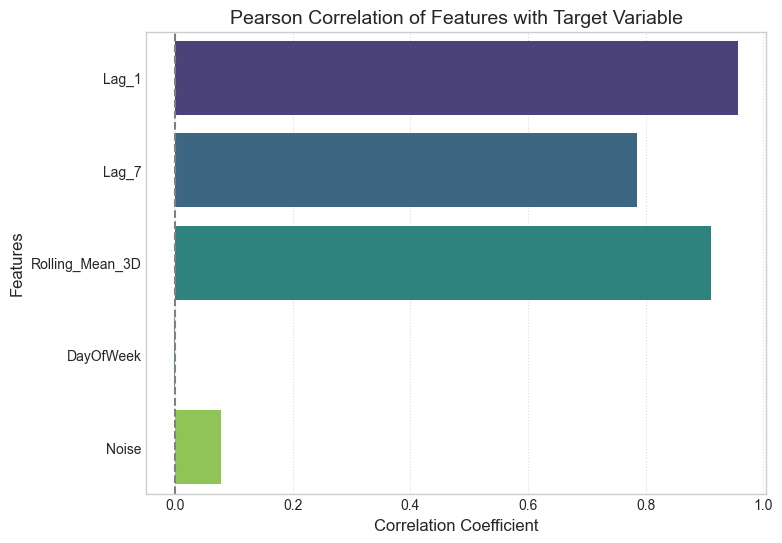


Features selected based on |correlation| >= 0.2:
['Lag_1', 'Lag_7', 'Rolling_Mean_3D']


In [4]:
# --- Calculate Pearson Correlation with Target ---
print("--- Pearson Correlation of Features with Target ---")
correlations = full_df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
print(correlations.sort_values(ascending=False))

# --- Visualize Correlations ---
plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")
plt.title('Pearson Correlation of Features with Target Variable', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.show()

# --- Conceptual Filtering ---
correlation_threshold = 0.2
selected_features_corr = correlations[abs(correlations) >= correlation_threshold].index.tolist()
print(f"\nFeatures selected based on |correlation| >= {correlation_threshold}:")
print(selected_features_corr)

#### 02. Fit L1 (Lasso) regression to estimate importance


--- L1 Regularization Feature Importance ---
           Feature  OLS_Coefficient  L1_Coefficient
0            Lag_1       146.932032      143.438341
1            Lag_7        16.688602       16.112838
3        DayOfWeek         3.317039        3.197577
4            Noise        -2.434231       -2.356407
2  Rolling_Mean_3D       -48.771416      -44.825852


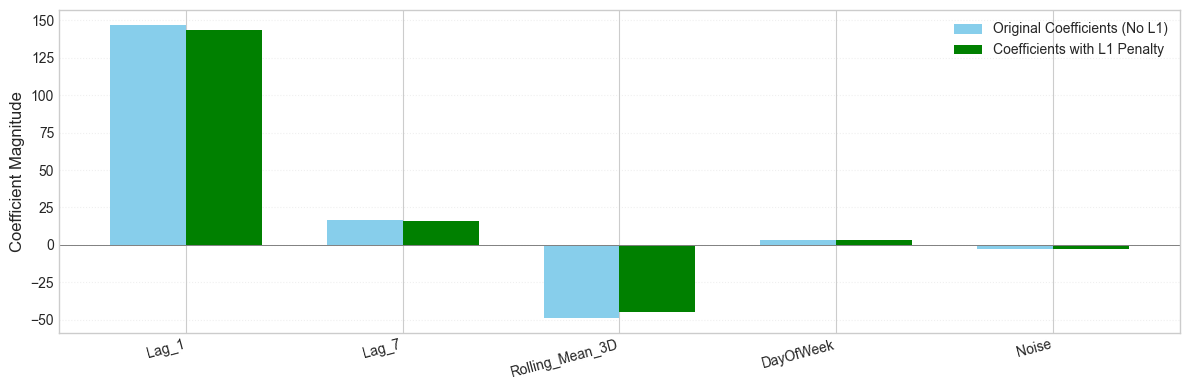

In [5]:
# Split data
X = full_df[feature_cols]
y = full_df[target_col]

# --- 1. Fit Ordinary Linear Regression (No L1) ---
from sklearn.linear_model import LinearRegression

ols = Pipeline([
    ("scaler", StandardScaler()),
    ("ols", LinearRegression())
])
ols.fit(X, y)
ols_coeffs = ols.named_steps['ols'].coef_

# --- 2. Fit Lasso (L1 Regularization) ---
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1))
])
lasso.fit(X, y)
lasso_coeffs = lasso.named_steps['lasso'].coef_

# --- Build DataFrame ---
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'OLS_Coefficient': ols_coeffs,
    'L1_Coefficient': lasso_coeffs
})

print("\n--- L1 Regularization Feature Importance ---")
print(feature_importance.sort_values("L1_Coefficient", ascending=False))

# --- Plot ---
x_pos = np.arange(len(feature_cols))
bar_width = 0.35

plt.figure(figsize=(12, 4))
plt.bar(x_pos - bar_width/2, ols_coeffs, bar_width, 
        label='Original Coefficients (No L1)', color='skyblue')
plt.bar(x_pos + bar_width/2, lasso_coeffs, bar_width, 
        label='Coefficients with L1 Penalty', color='green')

plt.ylabel('Coefficient Magnitude', fontsize=12)
plt.xticks(x_pos, feature_cols, rotation=15, ha="right")
plt.legend(fontsize=10)
plt.axhline(0, color='grey', linewidth=0.7)
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


#### 03. Tree-Based Feature Importance


--- Random Forest Feature Importance ---
           Feature  Importance
0            Lag_1    0.853089
2  Rolling_Mean_3D    0.109219
1            Lag_7    0.016912
4            Noise    0.015424
3        DayOfWeek    0.005356


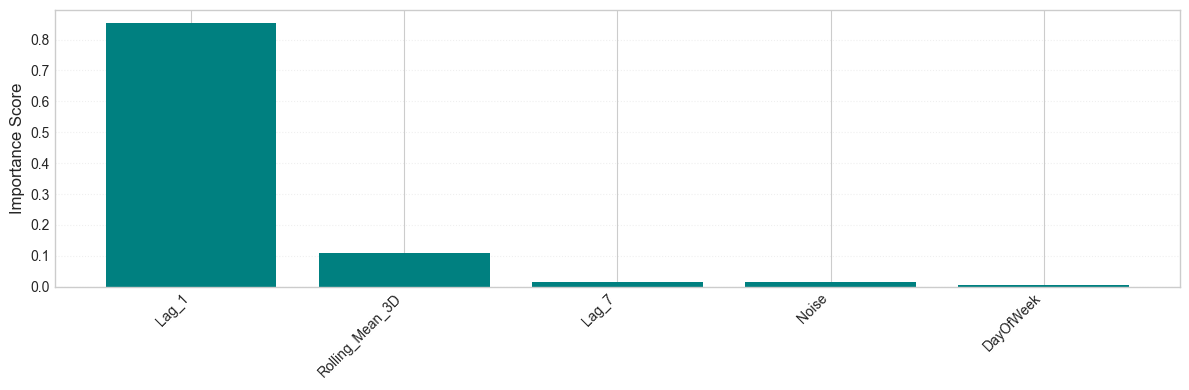

In [6]:
# Split data
X = full_df[feature_cols]
y = full_df[target_col]

# --- 1. Fit Random Forest ---
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

rf.fit(X, y)
rf_importance = rf.feature_importances_

# --- Build Importance Table ---

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

print("\n--- Random Forest Feature Importance ---")
print(importance_df)

# --- Plot ---

plt.figure(figsize=(12, 4))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='teal')

plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

### <span style="color:blue">Forecasting with Linear Regression

--- Linear Regression Model ---
Intercept: 2.2448
Coefficients:
  Lag_1: 1.2308
  Lag_7: 0.1082
  Rolling_Mean_3D: -0.3530
  DayOfWeek: 1.6074
  Noise: -0.2093


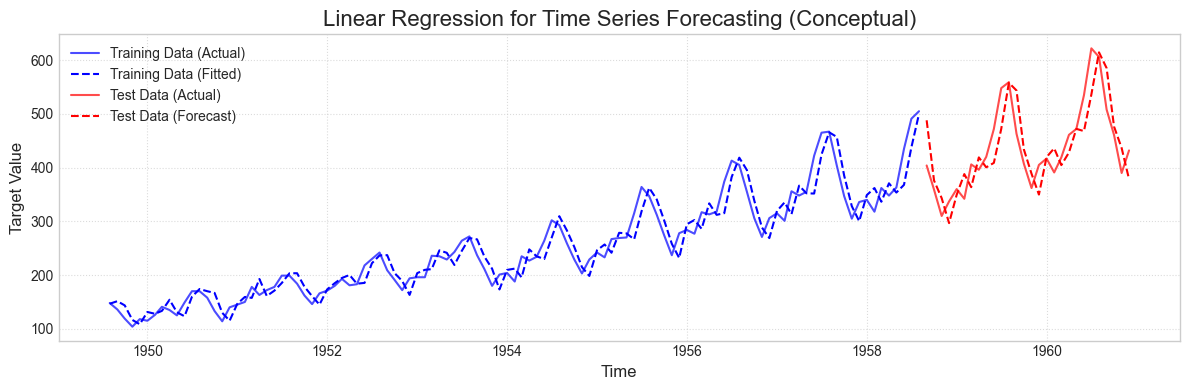

In [7]:
X = full_df[feature_cols]
y_target = full_df[target_col]

# --- Simple Train-Test Split (Chronological) ---
# For proper time series validation
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_target[:train_size], y_target[train_size:]

# --- Fit Linear Regression Model ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- Make Predictions ---
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

print("--- Linear Regression Model ---")
print(f"Intercept: {lr_model.intercept_:.4f}")
print("Coefficients:")
for feature, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")

# --- 5. Visualize Fit and Forecasts ---
plt.figure(figsize=(12, 4))
plt.plot(y_train.index, y_train, label='Training Data (Actual)', color='blue', alpha=0.7)
plt.plot(y_train.index, y_pred_train, label='Training Data (Fitted)', color='blue', linestyle='--')
plt.plot(y_test.index, y_test, label='Test Data (Actual)', color='red', alpha=0.7)
plt.plot(y_test.index, y_pred_test, label='Test Data (Forecast)', color='red', linestyle='--')

plt.title('Linear Regression for Time Series Forecasting (Conceptual)', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Target Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### <span style="color:blue">Forecasting with Random Forest

--- Forecasting with Random Forest ---
Fitting Random Forest model...
Model fitting complete.

Random Forest Test RMSE: 61.9303


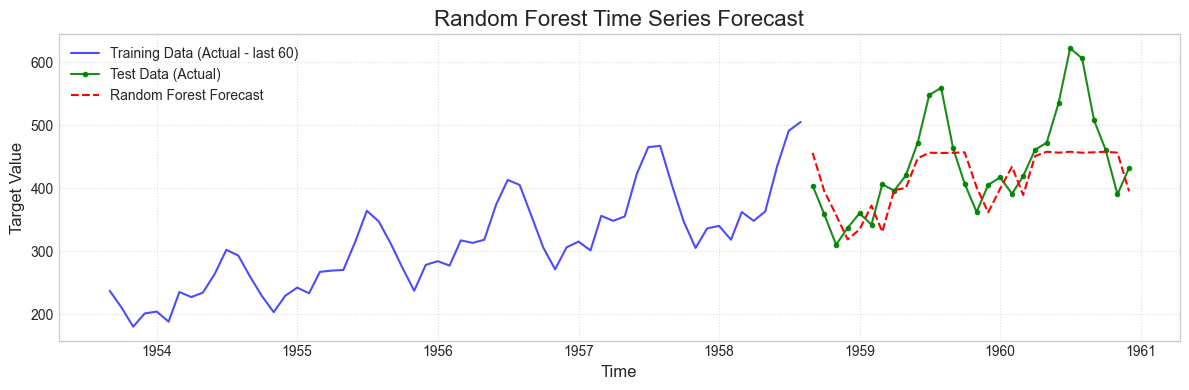


--- Random Forest Feature Importances ---
           Feature  Importance
0            Lag_1    0.813227
2  Rolling_Mean_3D    0.151647
1            Lag_7    0.022304
4            Noise    0.008753
3        DayOfWeek    0.004069


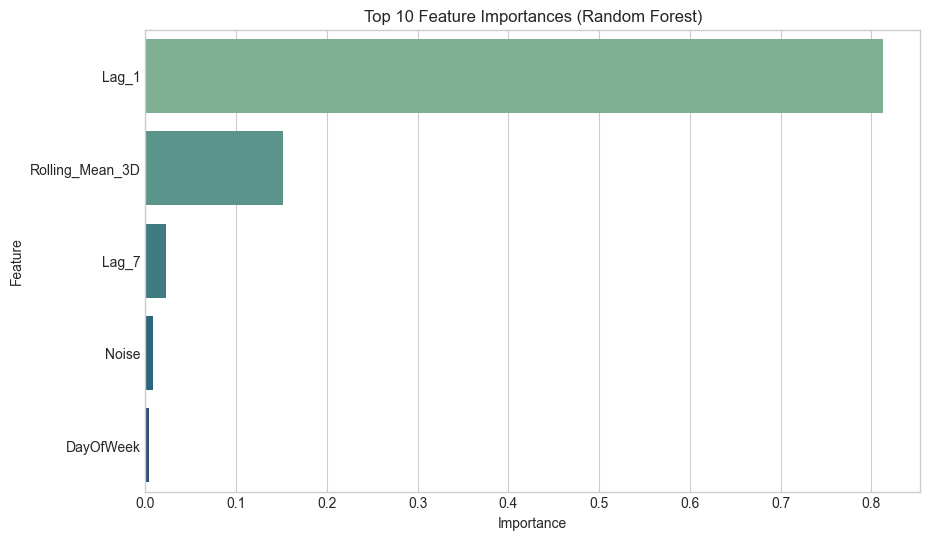

In [8]:
X = full_df[feature_cols]
y_target = full_df[target_col]

# --- Simple Train-Test Split (Chronological) ---
# For proper time series validation
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_target[:train_size], y_target[train_size:]

# ---------------------------------------------------------------------------

print("--- Forecasting with Random Forest ---")

# --- Instantiate RandomForestRegressor ---
rf_model = RandomForestRegressor(
    n_estimators=100,     # Number of trees in the forest
    max_depth=10,         # Maximum depth of each tree (helps prevent overfitting)
    min_samples_split=5,  # Minimum number of samples required to split an internal node
    min_samples_leaf=3,   # Minimum number of samples required to be at a leaf node
    random_state=42,      # For reproducibility
    n_jobs=-1             # Use all available CPU cores
)

# --- Fit the Model on Training Data ---
print("Fitting Random Forest model...")
rf_model.fit(X_train, y_train)
print("Model fitting complete.")

# ---  Generate Predictions on the Test Set ---
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_series = pd.Series(y_pred_rf, index=X_test.index) # Convert to Series for plotting

# --- Evaluate (Example: RMSE) ---
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"\nRandom Forest Test RMSE: {rmse_rf:.4f}")

# ---  Visualize Forecasts ---
plt.figure(figsize=(12, 4))
plt.plot(y_train.index[-60:], y_train.iloc[-60:], label='Training Data (Actual - last 60)', color='blue', alpha=0.7)
plt.plot(y_test.index, y_test, label='Test Data (Actual)', color='green', marker='.', linestyle='-', alpha=0.9)
plt.plot(y_pred_rf_series.index, y_pred_rf_series, label='Random Forest Forecast', color='red', linestyle='--')

plt.title('Random Forest Time Series Forecast', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Target Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Feature Importances ---
importances_rf = rf_model.feature_importances_
feature_importance_df_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances_rf})
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

print("\n--- Random Forest Feature Importances ---")
print(feature_importance_df_rf.head())

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf.head(10), palette='crest') # Top 10
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

### <span style="color:blue">Forecasting with Gradient Boosting Regressor 

--- Forecasting with Gradient Boosting Regressor ---
Fitting Gradient Boosting model...
Model fitting complete.

Gradient Boosting Test RMSE: 60.7737


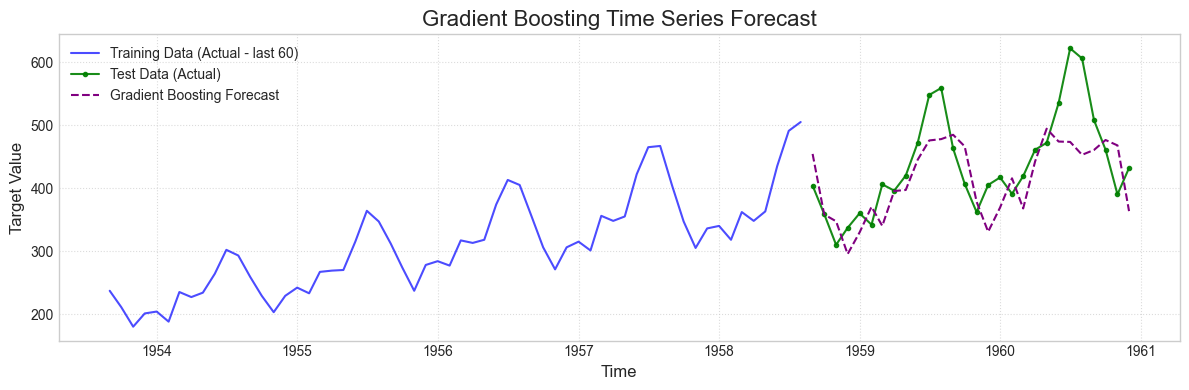


--- Gradient Boosting Feature Importances ---
           Feature  Importance
0            Lag_1    0.796763
2  Rolling_Mean_3D    0.131205
1            Lag_7    0.040577
4            Noise    0.023144
3        DayOfWeek    0.008310


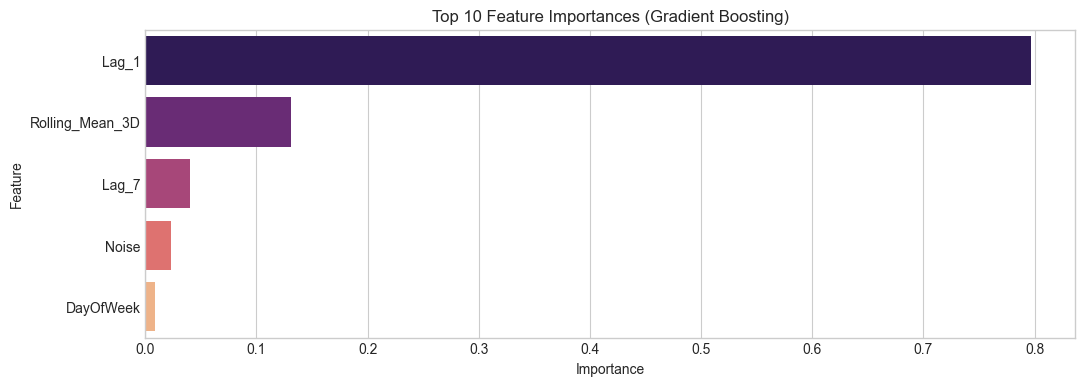

In [9]:
X = full_df[feature_cols]
y_target = full_df[target_col]

# --- Simple Train-Test Split (Chronological) ---
# For proper time series validatio
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_target[:train_size], y_target[train_size:]

# ---------------------------------------------------------------------------

print("--- Forecasting with Gradient Boosting Regressor ---")

# --- Instantiate GradientBoostingRegressor ---
gbm_model = GradientBoostingRegressor(
    n_estimators=100,     # Number of boosting stages (trees)
    learning_rate=0.1,    # Shrinks the contribution of each tree
    max_depth=3,          # Maximum depth of individual trees
    subsample=0.8,        # Fraction of samples to be used for fitting individual base learners
    random_state=42       # For reproducibility
)

# --- Fit the Model on Training Data ---
print("Fitting Gradient Boosting model...")
gbm_model.fit(X_train, y_train)
print("Model fitting complete.")

# --- Generate Predictions on the Test Set ---
y_pred_gbm = gbm_model.predict(X_test)
y_pred_gbm_series = pd.Series(y_pred_gbm, index=X_test.index) # Convert to Series for plotting

# --- Evaluate (Example: RMSE) ---
rmse_gbm = np.sqrt(mean_squared_error(y_test, y_pred_gbm))
print(f"\nGradient Boosting Test RMSE: {rmse_gbm:.4f}")

# --- Visualize Forecasts ---
plt.figure(figsize=(12, 4))
plt.plot(y_train.index[-60:], y_train.iloc[-60:], label='Training Data (Actual - last 60)', color='blue', alpha=0.7)
plt.plot(y_test.index, y_test, label='Test Data (Actual)', color='green', marker='.', linestyle='-', alpha=0.9)
plt.plot(y_pred_gbm_series.index, y_pred_gbm_series, label='Gradient Boosting Forecast', color='purple', linestyle='--')

plt.title('Gradient Boosting Time Series Forecast', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Target Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Feature Importances ---
importances_gbm = gbm_model.feature_importances_
feature_importance_df_gbm = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances_gbm})
feature_importance_df_gbm = feature_importance_df_gbm.sort_values(by='Importance', ascending=False)

print("\n--- Gradient Boosting Feature Importances ---")
print(feature_importance_df_gbm.head())

plt.figure(figsize=(12,4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_gbm.head(10), palette='magma') # Top 10
plt.title('Top 10 Feature Importances (Gradient Boosting)')
plt.show()

### <span style="color:blue">Hyperparameter tuning strategies for time series

#### 01. GRID SEARCH: Exhaustive search on a small hyperparameter grid

In [10]:
X = full_df[feature_cols]
y_target = full_df[target_col]

# --- Simple Train-Test Split (Chronological) ---
# For proper time series validation
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_target[:train_size], y_target[train_size:]


print("--- Hyperparameter Tuning: Grid Search vs Randomized Search (GBM) ---")

# ------------------------------------------------------------
# Gradient Boosting Base Model
# ------------------------------------------------------------
gbm_base = GradientBoostingRegressor(random_state=42)

# ------------------------------------------------------------
# GRID SEARCH: Exhaustive search on a small hyperparameter grid
# ------------------------------------------------------------
grid_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=gbm_base,
    param_grid=grid_params,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Running Grid Search...")
grid_search.fit(X_train, y_train)
print("Grid Search Complete.")

print("\nBest Grid Search Parameters:")
print(grid_search.best_params_)

best_gbm_grid = grid_search.best_estimator_

# Evaluate on test set
y_pred_grid = best_gbm_grid.predict(X_test)
rmse_grid = np.sqrt(mean_squared_error(y_test, y_pred_grid))
print(f"Grid Search Test RMSE: {rmse_grid:.4f}")


--- Hyperparameter Tuning: Grid Search vs Randomized Search (GBM) ---
Running Grid Search...
Grid Search Complete.

Best Grid Search Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Grid Search Test RMSE: 58.4530


#### 02. RANDOMIZED SEARCH: Faster sampling of combinations

In [11]:
X = full_df[feature_cols]
y_target = full_df[target_col]

# --- Simple Train-Test Split (Chronological) ---
# For proper time series validation
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_target[:train_size], y_target[train_size:]


print("--- Hyperparameter Tuning: Grid Search vs Randomized Search (GBM) ---")

# ------------------------------------------------------------
# Gradient Boosting Base Model
# ------------------------------------------------------------
gbm_base = GradientBoostingRegressor(random_state=42)


# ------------------------------------------------------------
# RANDOMIZED SEARCH: Faster sampling of combinations
# ------------------------------------------------------------
rand_params = {
    'n_estimators': np.arange(50, 300),
    'learning_rate': np.linspace(0.01, 0.2, 50),
    'max_depth': np.arange(2, 6),
    'subsample': np.linspace(0.5, 1.0, 20)
}

random_search = RandomizedSearchCV(
    estimator=gbm_base,
    param_distributions=rand_params,
    n_iter=30,                  # Only sample 30 combinations
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

print("\nRunning Randomized Search...")
random_search.fit(X_train, y_train)
print("Randomized Search Complete.")

print("\nBest Randomized Search Parameters:")
print(random_search.best_params_)

best_gbm_rand = random_search.best_estimator_

# Evaluate on test set
y_pred_rand = best_gbm_rand.predict(X_test)
rmse_rand = np.sqrt(mean_squared_error(y_test, y_pred_rand))
print(f"Random Search Test RMSE: {rmse_rand:.4f}")


--- Hyperparameter Tuning: Grid Search vs Randomized Search (GBM) ---

Running Randomized Search...
Randomized Search Complete.

Best Randomized Search Parameters:
{'subsample': 1.0, 'n_estimators': 143, 'max_depth': 2, 'learning_rate': 0.07204081632653062}
Random Search Test RMSE: 65.3003


### <span style="color:blue">Example of Time Series Split Folds</span>


#### 01. Incorrect Method: Regular KFold for Time Series

In [12]:
X = full_df[feature_cols]
y_target = full_df[target_col]


print("\n--- Incorrect CV: Regular K-Fold (Shuffles time order) ---")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_rmse = []

for train_idx, test_idx in kf.split(X):
    model = GradientBoostingRegressor(random_state=42)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(X.iloc[test_idx])
    rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], pred))
    kf_rmse.append(rmse)

print("Avg RMSE (Incorrect KFold):", np.round(np.mean(kf_rmse), 4))



--- Incorrect CV: Regular K-Fold (Shuffles time order) ---
Avg RMSE (Incorrect KFold): 38.4769


#### 02. Correct Method: TimeSeriesSplit (Walk-Forward CV)

In [13]:
print("\n--- Correct CV: TimeSeriesSplit (Walk-Forward) ---")

tscv = TimeSeriesSplit(n_splits=5)
tscv_rmse = []

for train_idx, test_idx in tscv.split(X):
    model = GradientBoostingRegressor(random_state=42)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(X.iloc[test_idx])
    rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], pred))
    tscv_rmse.append(rmse)

print("Avg RMSE (TimeSeriesSplit):", np.round(np.mean(tscv_rmse), 4))



--- Correct CV: TimeSeriesSplit (Walk-Forward) ---
Avg RMSE (TimeSeriesSplit): 54.0064



--- Visualizing TimeSeriesSplit ---


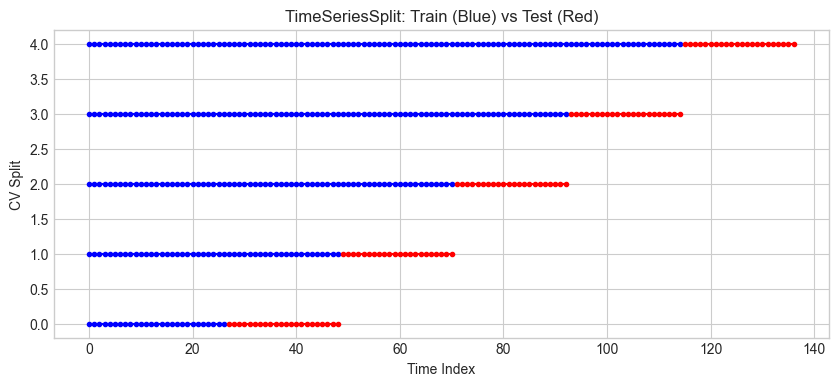

In [14]:
print("\n--- Visualizing TimeSeriesSplit ---")

n_samples = len(X)
splits = list(tscv.split(X))

plt.figure(figsize=(10, 4))

for i, (train_idx, test_idx) in enumerate(splits):
    plt.plot(train_idx, [i]*len(train_idx), marker='.', color='blue')
    plt.plot(test_idx, [i]*len(test_idx), marker='.', color='red')

plt.xlabel("Time Index")
plt.ylabel("CV Split")
plt.title("TimeSeriesSplit: Train (Blue) vs Test (Red)")
plt.show()
